# Global Data on Sustainable Energy (2000-2020)
🌏⚡Explore 20-year Insights on Sustainable Energy⚡🌏

In [ ]:
import pandas as pd

# Replace with your raw GitHub data link
github_raw_link = "https://raw.githubusercontent.com/nrhdyh/price_of_petroleum/refs/heads/main/global-data-on-sustainable-energy.csv"

try:
    # Attempt to read the data, assuming it's a CSV file.
    # You might need to adjust this based on your data format (e.g., pd.read_excel, pd.read_json)
    df = pd.read_csv(github_raw_link)
    print("Data loaded successfully!")
    print(df.head())
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure the link is a valid raw GitHub link and the data format is compatible with pd.read_csv (or adjust the read function).")

Data loaded successfully!
        Entity  Year  Access to electricity (% of population)  \
0  Afghanistan  2000                                 1.613591   
1  Afghanistan  2001                                 4.074574   
2  Afghanistan  2002                                 9.409158   
3  Afghanistan  2003                                14.738506   
4  Afghanistan  2004                                20.064968   

   Access to clean fuels for cooking  \
0                                6.2   
1                                7.2   
2                                8.2   
3                                9.5   
4                               10.9   

   Renewable-electricity-generating-capacity-per-capita  \
0                                               9.22      
1                                               8.86      
2                                               8.47      
3                                               8.09      
4                                              

In [ ]:
print("\nFirst few rows of the dataset:")
print(df.head())

print("\nDataset structure (info()):")
df.info()

print("\nDataset size (shape):")
print(df.shape)


First few rows of the dataset:
        Entity  Year  Access to electricity (% of population)  \
0  Afghanistan  2000                                 1.613591   
1  Afghanistan  2001                                 4.074574   
2  Afghanistan  2002                                 9.409158   
3  Afghanistan  2003                                14.738506   
4  Afghanistan  2004                                20.064968   

   Access to clean fuels for cooking  \
0                                6.2   
1                                7.2   
2                                8.2   
3                                9.5   
4                               10.9   

   Renewable-electricity-generating-capacity-per-capita  \
0                                               9.22      
1                                               8.86      
2                                               8.47      
3                                               8.09      
4                                        

# **2. Data Pre-processing**

*   Data preprocessing is the essential, multi-step process of cleaning, transforming, and organizing raw, chaotic data into a structured format suitable for analysis or machine learning


In [ ]:
df

,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,"6,52,230",33.939110,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,"6,52,230",33.939110,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,"6,52,230",33.939110,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,"6,52,230",33.939110,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,"6,52,230",33.939110,67.709953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3644,Zimbabwe,2016,42.561730,29.8,62.88,30000.0,81.90,3.50,0.0,3.32,...,3227.68020,10.00,11020.000460,NaN,0.755869,1464.588957,38,"3,90,757",-19.015438,29.154857
3645,Zimbabwe,2017,44.178635,29.8,62.33,5570000.0,82.46,3.05,0.0,4.30,...,3068.01150,9.51,10340.000150,NaN,4.709492,1235.189032,38,"3,90,757",-19.015438,29.154857
3646,Zimbabwe,2018,45.572647,29.9,82.53,10000.0,80.23,3.73,0.0,5.46,...,3441.98580,9.83,12380.000110,NaN,4.824211,1254.642265,38,"3,90,757",-19.015438,29.154857
3647,Zimbabwe,2019,46.781475,30.1,81.40,250000.0,81.50,3.66,0.0,4.58,...,3003.65530,10.47,11760.000230,NaN,-6.144236,1316.740657,38,"3,90,757",-19.015438,29.154857


**Handle Missing Values**

In [ ]:
df_cleaned = df.copy()

print("Missing values before handling:")
print(df_cleaned.isnull().sum())

# Robustly clean all column names: replace newlines with spaces and strip whitespace
df_cleaned.columns = df_cleaned.columns.str.replace('\n', ' ').str.strip()

# Identify columns to drop based on high missing percentage
missing_percentage = df_cleaned.isnull().sum() / len(df_cleaned) * 100
cols_to_drop = missing_percentage[missing_percentage > 50].index.tolist()

if cols_to_drop:
    df_cleaned = df_cleaned.drop(columns=cols_to_drop)
    print(f"\nDropped columns with excessive missing values: {', '.join(cols_to_drop)}.")
else:
    print("\nNo columns with excessive missing values to drop.")


# Drop rows where the target variable 'Access to electricity (% of population)' is missing
initial_rows = df_cleaned.shape[0]
df_cleaned.dropna(subset=['Access to electricity (% of population)'], inplace=True)
rows_dropped_target = initial_rows - df_cleaned.shape[0]
print(f"Dropped {rows_dropped_target} rows with missing 'Access to electricity (%% of population)'.")

# Clean and convert 'Density (P/Km2)' and 'Land Area (Km2)' to numeric
# Assuming column names are now clean ('Density (P/Km2)', 'Land Area (Km2)')
if 'Density (P/Km2)' in df_cleaned.columns:
    df_cleaned['Density (P/Km2)'] = df_cleaned['Density (P/Km2)'].astype(str).str.replace(',', '', regex=False).astype(float)
    print("Converted 'Density (P/Km2)' to numeric type.")
else:
    print("'Density (P/Km2)' column not found or already handled.")

if 'Land Area (Km2)' in df_cleaned.columns:
    df_cleaned['Land Area (Km2)'] = df_cleaned['Land Area (Km2)'].astype(str).str.replace(',', '', regex=False).astype(float)
    print("Converted 'Land Area (Km2)' to numeric type.")
else:
    print("'Land Area (Km2)' column not found or already handled.")

# Impute remaining numerical missing values with the median
# Iterate only through existing numerical columns to avoid errors
for col in df_cleaned.select_dtypes(include=['float64', 'int64']).columns:
    if df_cleaned[col].isnull().any():
        median_val = df_cleaned[col].median()
        df_cleaned[col].fillna(median_val, inplace=True)
        print(f"Imputed missing values in '{col}' with the median.")

print("\nMissing values after handling:")
print(df_cleaned.isnull().sum())

print("\nDataFrame info after cleaning:")
df_cleaned.info()

print("\nFirst 5 rows of the cleaned DataFrame:")
display(df_cleaned.head())

Missing values before handling:
Entity                                                                 0
Year                                                                   0
Access to electricity (% of population)                               10
Access to clean fuels for cooking                                    169
Renewable-electricity-generating-capacity-per-capita                 931
Financial flows to developing countries (US $)                      2089
Renewable energy share in the total final energy consumption (%)     194
Electricity from fossil fuels (TWh)                                   21
Electricity from nuclear (TWh)                                       126
Electricity from renewables (TWh)                                     21
Low-carbon electricity (% electricity)                                42
Primary energy consumption per capita (kWh/person)                     0
Energy intensity level of primary energy (MJ/$2017 PPP GDP)          207
Value_co2_emissions

/tmp/ipykernel_3715/605358059.py:45: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[col].fillna(median_val, inplace=True)


,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,44.99,0.16,0.0,0.31,65.957440,302.59482,1.64,760.000000,3.559855,4588.143423,60,"6,52,230",33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,45.60,0.09,0.0,0.50,84.745766,236.89185,1.74,730.000000,3.559855,4588.143423,60,"6,52,230",33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,37.83,0.13,0.0,0.56,81.159424,210.86215,1.40,1029.999971,3.559855,179.426579,60,"6,52,230",33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,36.66,0.31,0.0,0.63,67.021280,229.96822,1.40,1220.000029,8.832278,190.683814,60,"6,52,230",33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,44.24,0.33,0.0,0.56,62.921350,204.23125,1.20,1029.999971,1.414118,211.382074,60,"6,52,230",33.93911,67.709953


**Remove Duplicates**

In [ ]:
initial_rows = df_cleaned.shape[0]
df_cleaned.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - df_cleaned.shape[0]

print(f"Number of duplicate rows removed: {duplicates_removed}")
print(f"Shape of DataFrame after removing duplicates: {df_cleaned.shape}")

Number of duplicate rows removed: 0
Shape of DataFrame after removing duplicates: (3639, 19)


**Removing Outliers**

In [ ]:
from sklearn.ensemble import IsolationForest
import numpy as np

# Create a copy to work with, specifically for outlier handling
df_cleaned_no_outliers = df_cleaned.copy()

print(f"Shape before outlier removal: {df_cleaned_no_outliers.shape}")

# Select only numerical columns for outlier detection
numerical_cols = df_cleaned_no_outliers.select_dtypes(include=np.number).columns.tolist()

# Exclude 'Year', 'Latitude', and 'Longitude' if they are not considered features for outlier detection
# Year is a time identifier, Latitude and Longitude are geographical coordinates
if 'Year' in numerical_cols:
    numerical_cols.remove('Year')
if 'Latitude' in numerical_cols:
    numerical_cols.remove('Latitude')
if 'Longitude' in numerical_cols:
    numerical_cols.remove('Longitude')

# Create a sub-dataframe with only numerical columns relevant for outlier detection
df_numerical_for_outliers = df_cleaned_no_outliers[numerical_cols].copy()

# Impute any remaining NaNs in these numerical columns before Isolation Forest
# Although previous steps aimed to remove all NaNs, this ensures robustness
for col in df_numerical_for_outliers.columns:
    if df_numerical_for_outliers[col].isnull().any():
        median_val = df_numerical_for_outliers[col].median()
        df_numerical_for_outliers[col].fillna(median_val, inplace=True)

# Initialize and train the Isolation Forest model
# contamination: The proportion of outliers in the data set. Common values are 0.01 to 0.1.
iso_forest = IsolationForest(random_state=42, contamination=0.05) # Assuming 5% outliers

# Fit the model and predict outliers (-1 for outliers, 1 for inliers)
df_cleaned_no_outliers['is_outlier'] = iso_forest.fit_predict(df_numerical_for_outliers)

# Filter out the outliers
df_cleaned_no_outliers_filtered = df_cleaned_no_outliers[df_cleaned_no_outliers['is_outlier'] == 1]

# Calculate number of outliers removed
num_outliers_removed = df_cleaned_no_outliers.shape[0] - df_cleaned_no_outliers_filtered.shape[0]

# Drop the temporary 'is_outlier' column
df_cleaned_no_outliers = df_cleaned_no_outliers_filtered.drop(columns=['is_outlier']).copy()

print(f"Number of outliers removed: {num_outliers_removed}")
print(f"Shape after outlier removal: {df_cleaned_no_outliers.shape}")

print("\nFirst 5 rows of DataFrame after outlier handling:")
display(df_cleaned_no_outliers.head())

Shape before outlier removal: (3639, 19)
Number of outliers removed: 182
Shape after outlier removal: (3457, 19)

First 5 rows of DataFrame after outlier handling:


,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),Low-carbon electricity (% electricity),Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,44.99,0.16,0.0,0.31,65.957440,302.59482,1.64,760.000000,3.559855,4588.143423,60,"6,52,230",33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,45.60,0.09,0.0,0.50,84.745766,236.89185,1.74,730.000000,3.559855,4588.143423,60,"6,52,230",33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,37.83,0.13,0.0,0.56,81.159424,210.86215,1.40,1029.999971,3.559855,179.426579,60,"6,52,230",33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,36.66,0.31,0.0,0.63,67.021280,229.96822,1.40,1220.000029,8.832278,190.683814,60,"6,52,230",33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,44.24,0.33,0.0,0.56,62.921350,204.23125,1.20,1029.999971,1.414118,211.382074,60,"6,52,230",33.93911,67.709953


**Imputing value into missing values**

In [ ]:
print("\n--- Starting final missing value imputation ---")

# Check actual column names
print(df_cleaned.columns.tolist())

# Replace blank / empty strings with NaN
df_cleaned = df_cleaned.replace(r'^\s*$', np.nan, regex=True)

# Process all columns
for col in df_cleaned.columns:

    # If column has no data at all
    if df_cleaned[col].isnull().all():
        print(f"{col} has no data at all. Dropping column.")
        df_cleaned.drop(columns=[col], inplace=True)
        continue

    # Try to clean numeric-looking values
    if df_cleaned[col].dtype == 'object':
        temp = (
            df_cleaned[col]
            .astype(str)
            .str.replace(',', '', regex=False)
            .str.replace('\\n', '', regex=False)
        )

        converted = pd.to_numeric(temp, errors='coerce')

        # Convert only if most values are numeric
        if converted.notna().sum() >= df_cleaned[col].notna().sum() * 0.8:
            df_cleaned[col] = converted

    # Impute numeric columns with median
    if pd.api.types.is_numeric_dtype(df_cleaned[col]):
        if df_cleaned[col].isnull().any():
            median_val = df_cleaned[col].median()
            df_cleaned[col] = df_cleaned[col].fillna(median_val)
            print(f"{col} imputed with median: {median_val}")

    # Impute categorical/text columns with mode
    else:
        if df_cleaned[col].isnull().any():
            mode_val = df_cleaned[col].mode()[0]
            df_cleaned[col] = df_cleaned[col].fillna(mode_val)
            print(f"{col} imputed with mode: {mode_val}")


print("\n--- Missing values after imputation ---")
print(df_cleaned.isnull().sum())

print("\nTotal missing values:")
print(df_cleaned.isnull().sum().sum())


--- Starting final missing value imputation ---
['Entity', 'Year', 'Access to electricity (% of population)', 'Access to clean fuels for cooking', 'Renewable-electricity-generating-capacity-per-capita', 'Renewable energy share in the total final energy consumption (%)', 'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)', 'Electricity from renewables (TWh)', 'Low-carbon electricity (% electricity)', 'Primary energy consumption per capita (kWh/person)', 'Energy intensity level of primary energy (MJ/$2017 PPP GDP)', 'Value_co2_emissions_kt_by_country', 'gdp_growth', 'gdp_per_capita', 'Density\\n(P/Km2)', 'Land Area(Km2)', 'Latitude', 'Longitude']

--- Missing values after imputation ---
Entity                                                              0
Year                                                                0
Access to electricity (% of population)                             0
Access to clean fuels for cooking                                   0
Renew

**Final checx for missing values**

In [ ]:
print("Final check for missing values in df_cleaned:")
print(df_cleaned.isnull().sum())

Final check for missing values in df_cleaned:
Entity                                                              0
Year                                                                0
Access to electricity (% of population)                             0
Access to clean fuels for cooking                                   0
Renewable-electricity-generating-capacity-per-capita                0
Renewable energy share in the total final energy consumption (%)    0
Electricity from fossil fuels (TWh)                                 0
Electricity from nuclear (TWh)                                      0
Electricity from renewables (TWh)                                   0
Low-carbon electricity (% electricity)                              0
Primary energy consumption per capita (kWh/person)                  0
Energy intensity level of primary energy (MJ/$2017 PPP GDP)         0
Value_co2_emissions_kt_by_country                                   0
gdp_growth                                  

**Box Plot (before & after) outliers removal.**

Displaying box plots for 'Access to electricity (% of population)' BEFORE outlier removal.


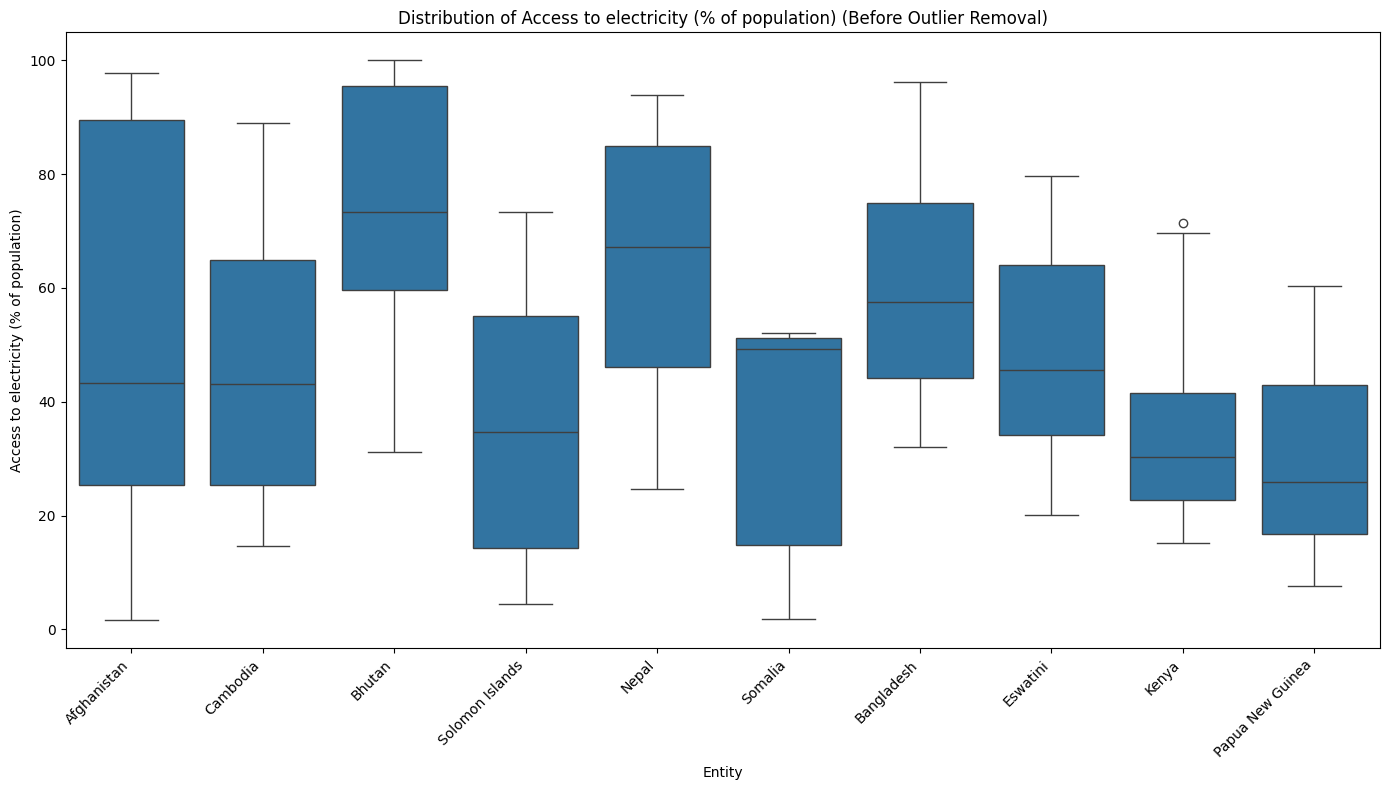


Displaying box plots for 'Access to electricity (% of population)' AFTER outlier removal.


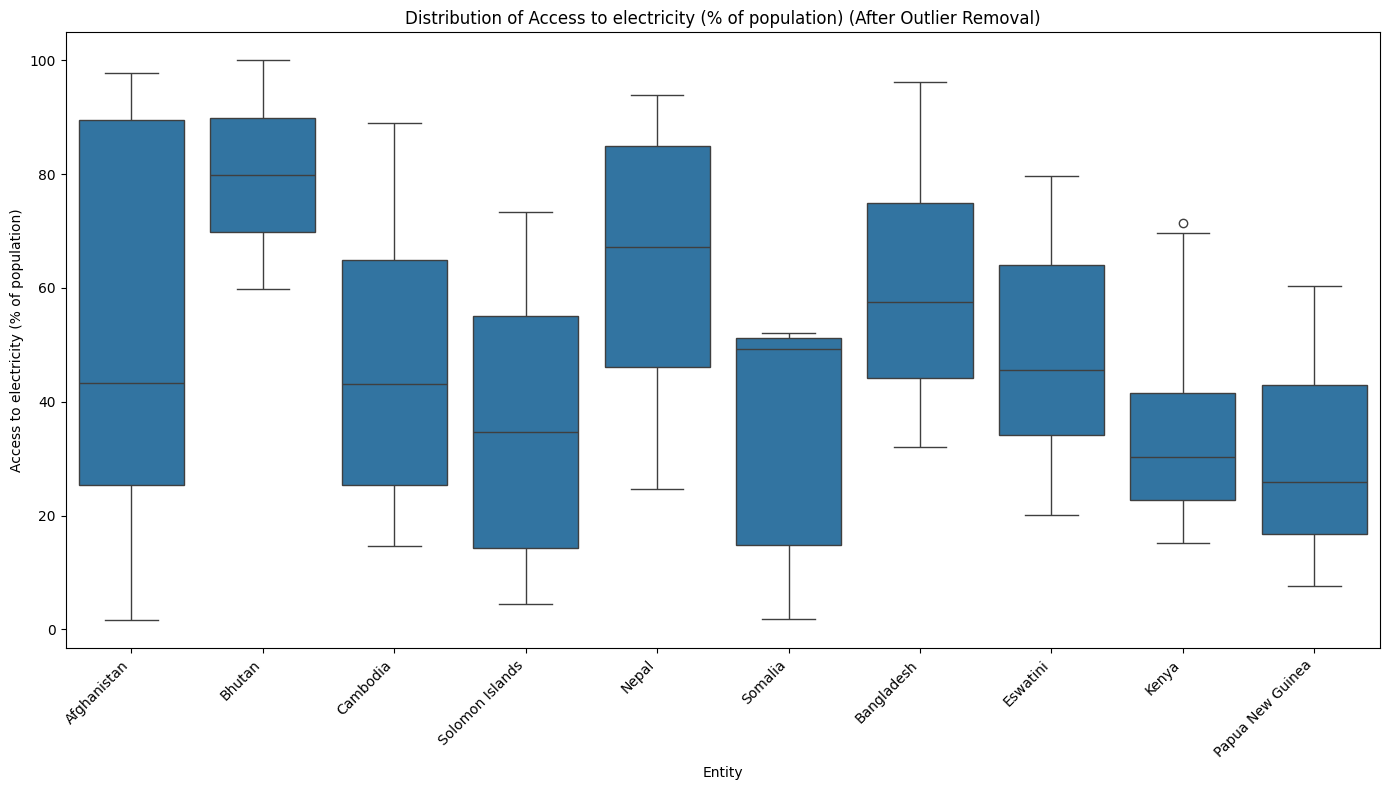

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

column_to_plot = 'Access to electricity (% of population)'

# --- Box Plot BEFORE Outlier Removal ---
print(f"Displaying box plots for '{column_to_plot}' BEFORE outlier removal.")

# Calculate the standard deviation of 'Access to electricity (% of population)' for each entity in df_cleaned
entity_std_dev_before = df_cleaned.groupby('Entity')[column_to_plot].std().nlargest(10).index

# Filter df_cleaned to include only these entities with highest variance
df_high_variance_entities_before = df_cleaned[df_cleaned['Entity'].isin(entity_std_dev_before)].copy()

plt.figure(figsize=(14, 8))
sns.boxplot(x='Entity', y=column_to_plot, data=df_high_variance_entities_before, order=entity_std_dev_before)
plt.title(f'Distribution of {column_to_plot} (Before Outlier Removal)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Box Plot AFTER Outlier Removal ---
print(f"\nDisplaying box plots for '{column_to_plot}' AFTER outlier removal.")

# Calculate the standard deviation of 'Access to electricity (% of population)' for each entity in df_cleaned_no_outliers
entity_std_dev_after = df_cleaned_no_outliers.groupby('Entity')[column_to_plot].std().nlargest(10).index

# Filter df_cleaned_no_outliers to include only these entities with highest variance
df_high_variance_entities_after = df_cleaned_no_outliers[df_cleaned_no_outliers['Entity'].isin(entity_std_dev_after)].copy()

plt.figure(figsize=(14, 8))
sns.boxplot(x='Entity', y=column_to_plot, data=df_high_variance_entities_after, order=entity_std_dev_after)
plt.title(f'Distribution of {column_to_plot} (After Outlier Removal)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Explaining relationship between attributes**

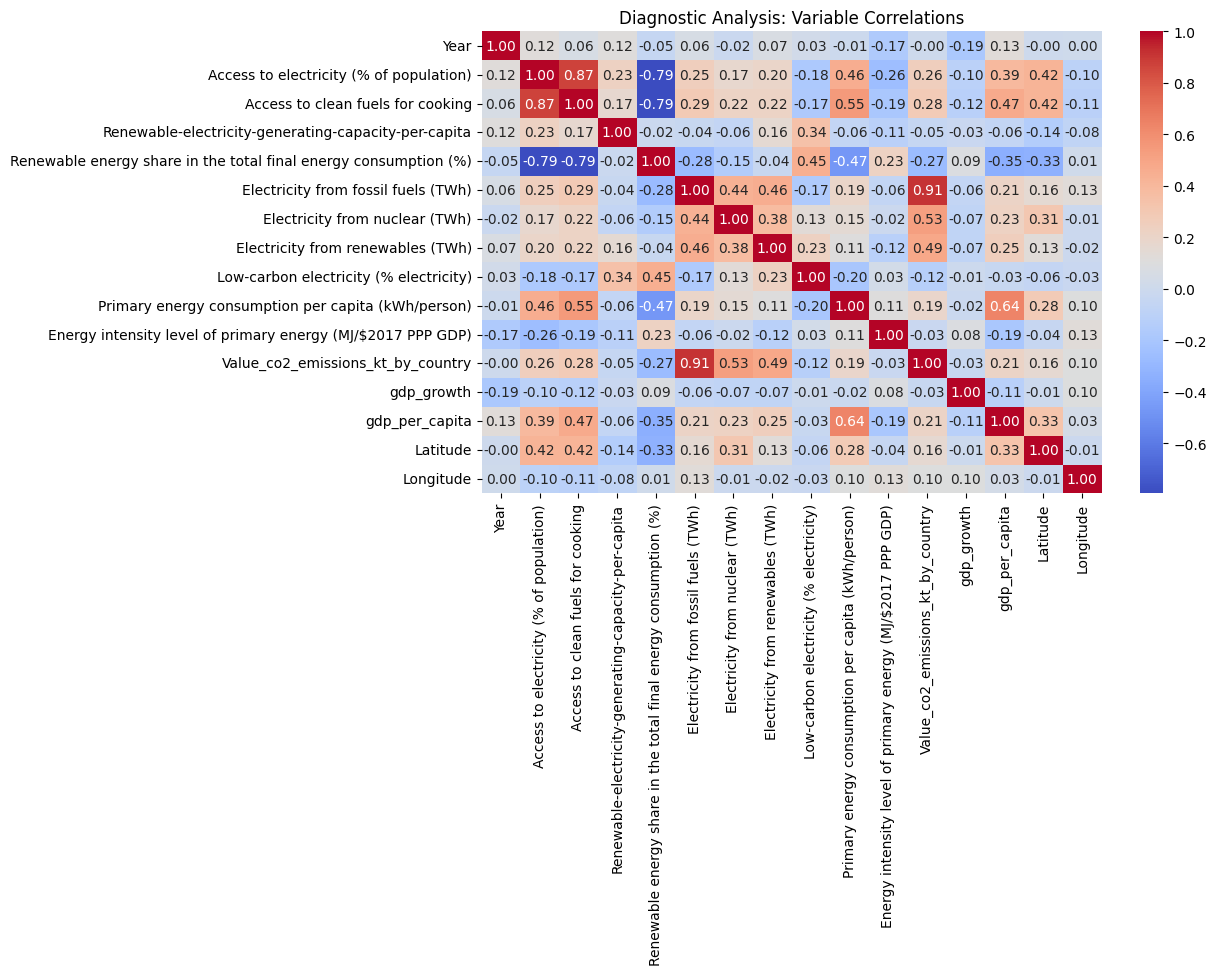

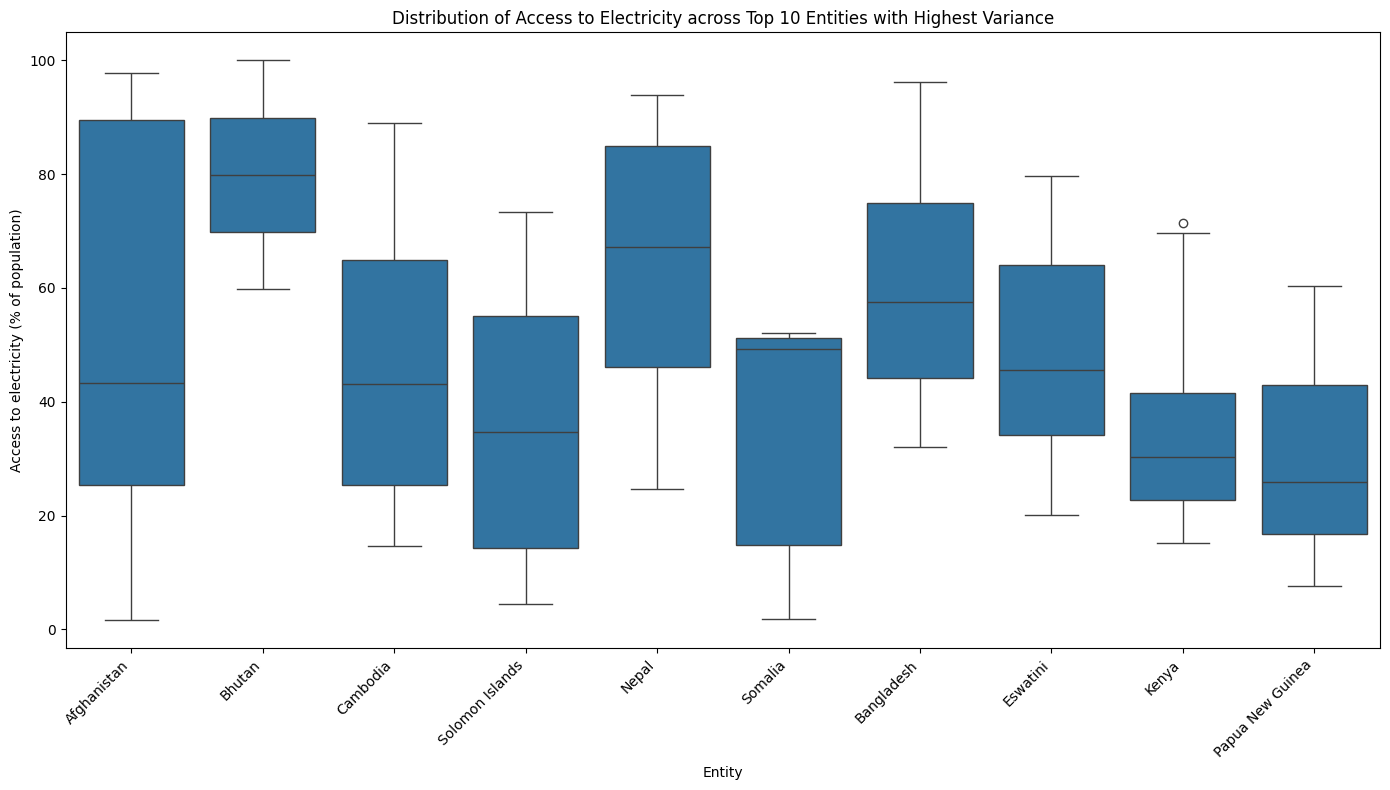

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 2.1 Correlation Heatmap (Explaining relationships)
plt.figure(figsize=(10, 6))
# select_dtypes(include='number') ensures we only correlate numerical data
correlation_matrix = df_cleaned_no_outliers.select_dtypes(include='number').corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Diagnostic Analysis: Variable Correlations")
plt.show()

# 2.2 Comparative Visualization
# To make the boxplot more informative, let's look at entities with the most variance in access to electricity
# This will avoid flat lines for countries with consistently 100% access.

# Calculate the standard deviation of 'Access to electricity (% of population)' for each entity
entity_std_dev = df_cleaned_no_outliers.groupby('Entity')['Access to electricity (% of population)'].std().nlargest(10).index

# Filter the DataFrame to include only these entities with highest variance
df_high_variance_entities = df_cleaned_no_outliers[df_cleaned_no_outliers['Entity'].isin(entity_std_dev)]

plt.figure(figsize=(14, 8)) # Increased figure size for better readability
sns.boxplot(x='Entity', y='Access to electricity (% of population)', data=df_high_variance_entities, order=entity_std_dev)
plt.title("Distribution of Access to Electricity across Top 10 Entities with Highest Variance")
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better visibility and alignment
plt.tight_layout()
plt.show()

## 3. Machine Learning: Prediction Model

In this section, we will build a simple linear regression model to predict 'Access to electricity (% of population)' based on several key features.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 3.1 Define Features (X) and Target (y)
# We will use 'Access to electricity (% of population)' as our target (y)
# and 'Year', 'Access to clean fuels for cooking', 'gdp_per_capita',
# and 'Renewable energy share in the total final energy consumption (%)' as features (X).

X = df_cleaned_no_outliers[['Year', 'Access to clean fuels for cooking', 'gdp_per_capita', 'Renewable energy share in the total final energy consumption (%)']]
y = df_cleaned_no_outliers['Access to electricity (% of population)']

# Display the first few rows of the features and target
print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,Year,Access to clean fuels for cooking,gdp_per_capita,Renewable energy share in the total final energy consumption (%)
0,2000,6.2,4588.143423,44.99
1,2001,7.2,4588.143423,45.60
2,2002,8.2,179.426579,37.83
3,2003,9.5,190.683814,36.66
4,2004,10.9,211.382074,44.24



Target (y) head:


,Access to electricity (% of population)
0,1.613591
1,4.074574
2,9.409158
3,14.738506
4,20.064968


In [ ]:
# 3.2 Split data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2765, 4)
X_test shape: (692, 4)
y_train shape: (2765,)
y_test shape: (692,)


In [ ]:
# 3.3 Create and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


Model Accuracy (R2 Score): 0.77
Mean Squared Error: 201.11


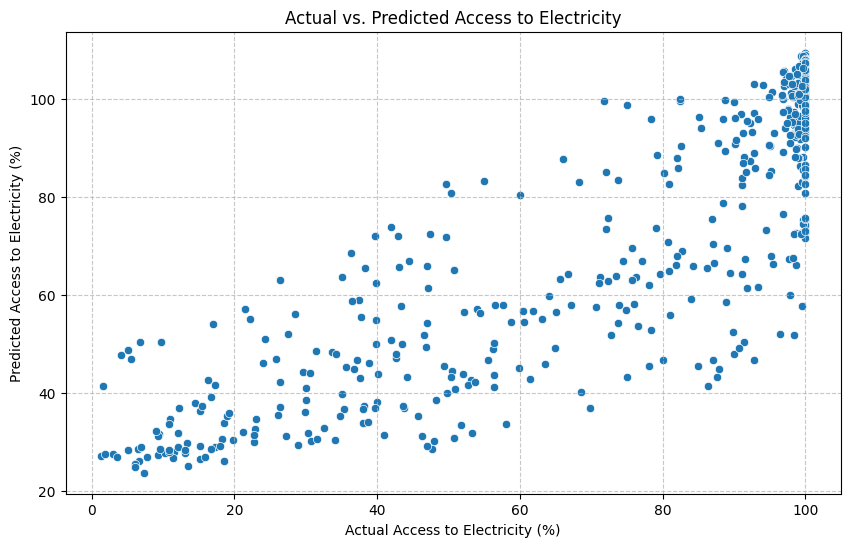

In [ ]:
# 3.4 Make Predictions and Evaluate
predictions = model.predict(X_test)

print(f"Model Accuracy (R2 Score): {r2_score(y_test, predictions):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, predictions):.2f}")

# Optionally, visualize predictions vs actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=predictions)
plt.xlabel("Actual Access to Electricity (%)")
plt.ylabel("Predicted Access to Electricity (%)")
plt.title("Actual vs. Predicted Access to Electricity")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Save cleaned dataframe to CSV
df_cleaned.to_csv('cleaned_energy_data4.csv', index=False)

print("CSV file saved successfully!")

CSV file saved successfully!


In [ ]:
!pip install streamlit pandas plotly pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 83.4 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
import numpy as np

# Set Page Config
st.set_page_config(page_title="Big Data Energy Insights", layout="wide")
st.title("⚡ Sustainable Energy: Analysis & Prediction Dashboard")
st.markdown("---")

# Load Data (Phase 2 Output)
@st.cache_data
def load_data():
    df = pd.read_csv("cleaned_energy_data.csv")
    return df

df = load_data()

# --- SIDEBAR FILTERS ---
st.sidebar.header("Global Filters")
countries = st.sidebar.multiselect("Select Countries", options=df['Entity'].unique(), default=["Malaysia"])
year_range = st.sidebar.slider("Year Range", int(df['Year'].min()), int(df['Year'].max()), (2000, 2020))

# Filtered Dataframe
mask = (df['Entity'].isin(countries)) & (df['Year'].between(year_range[0], year_range[1]))
filtered_df = df[mask]

# --- DASHBOARD TABS ---
tab1, tab2, tab3 = st.tabs(["📊 Descriptive Analysis", "🔍 Diagnostic Heatmaps", "🤖 Predictive Model"])

# --- TAB 1: DESCRIPTIVE (From your Code Tab 1 & 2) ---
with tab1:
    st.header("Access to Electricity Overview")
    col1, col2 = st.columns([1, 2])

    with col1:
        st.subheader("Summary Stats")
        st.write(filtered_df['Access to electricity (% of population)'].describe())

    with col2:
        st.subheader("Yearly Trend")
        # Visualizing your trend logic from Tab 1.3
        trend_data = filtered_df.groupby('Year')['Access to electricity (% of population)'].mean().reset_index()
        fig_trend = px.line(trend_data, x='Year', y='Access to electricity (% of population)', markers=True)
        st.plotly_chart(fig_trend, use_container_width=True)

# --- TAB 2: DIAGNOSTIC (From your Code Tab 2) ---
with tab2:
    st.header("Variable Correlations & Distribution")
    col3, col4 = st.columns(2)

    with col3:
        st.subheader("Correlation Heatmap")
        corr = df.select_dtypes(include='number').corr()
        fig_heat = px.imshow(corr, text_auto=True, color_continuous_scale='RdBu_r')
        st.plotly_chart(fig_heat, use_container_width=True)

    with col4:
        st.subheader("Variance in Electricity Access")
        # Your Boxplot logic from Tab 2.2
        fig_box = px.box(filtered_df, x='Entity', y='Access to electricity (% of population)', color='Entity')
        st.plotly_chart(fig_box, use_container_width=True)

# --- TAB 3: PREDICTIVE (From your Code Tab 3, 5, & 6) ---
with tab3:
    st.header("Predicting Access to Electricity")

    # Train model on the fly using your Phase 3 Logic
    X_cols = ['Year', 'Access to clean fuels for cooking', 'gdp_per_capita', 'Renewable energy share in the total final energy consumption (%)']
    model_df = df.dropna(subset=X_cols + ['Access to electricity (% of population)'])

    X = model_df[X_cols]
    y = model_df['Access to electricity (% of population)']

    model = LinearRegression()
    model.fit(X, y)

    # Simple Prediction UI
    st.subheader("Make a Prediction")
    p_year = st.number_input("Enter Year", value=2025)
    p_fuels = st.slider("Clean Fuel Access (%)", 0, 100, 50)
    p_gdp = st.number_input("GDP Per Capita", value=float(df['gdp_per_capita'].mean()))
    p_renew = st.slider("Renewable Share (%)", 0, 100, 20)

    input_data = np.array([[p_year, p_fuels, p_gdp, p_renew]])
    prediction = model.predict(input_data)

    st.success(f"Predicted Access to Electricity: **{prediction[0]:.2f}%**")

Writing app.py
